In [1]:
%cd ..

C:\Users\malte\EvoMUSART23-repro-code


In [2]:
from evoaudio.sample_library import SampleLibrary
sample_lib = SampleLibrary()

Loading samples:   0%|          | 0/6826 [00:00<?, ?it/s]

In [3]:
import os
import pickle
import pandas as pd
from evoaudio.population import Population

BASE_DIR = os.path.join("experiments", "moea")
def parse_objectives(filename):
    name = filename.replace(".pkl", "")
    objectives = name.split("__")
    return objectives, len(objectives)

def parse_filename(filename):
    """
    Expected new format:
        {run_id}__{objective1}__{objective2}__... .pkl

    Returns:
        run_id (int or None)
        objectives (tuple[str])
        n_objectives (int)
    """
    name = filename.replace(".pkl", "")
    parts = name.split("__")

    if parts[0].isdigit():
        run_id = int(parts[0])
        objectives = tuple(parts[1:])
    else:
        run_id = None
        objectives = tuple(parts)

    return run_id, objectives, len(objectives)

def compute_population_recall(population, restored_individuals):
    correct = 0
    total = len(restored_individuals)

    for idx, pop in population:
        pop._expand(sample_lib)
        gt_ind = restored_individuals[idx]
        gt_annotations = {(s.instrument, s.pitch) for s in gt_ind.samples}

        if any(
            {(s.instrument, s.pitch) for s in ind.samples} == gt_annotations
            for ind in pop.individuals
        ):
            correct += 1

    return correct, total, correct / total if total > 0 else 0.0


In [4]:
data_base_dir = os.path.join("experiments", "ground_truth_scan")

with open(os.path.join(data_base_dir, "ground_truth_dataset.pkl"), "rb") as f:
    restored_individuals = pickle.load(f)

In [5]:
import os
import pickle
import pandas as pd

results = []

for algorithm in ["smsemoa", "nsga2"]:
    algo_dir = os.path.join(BASE_DIR, algorithm)

    for selection in ["random", "recall", "shapley_recall"]:
        sel_dir = os.path.join(algo_dir, selection)

        if not os.path.exists(sel_dir):
            continue

        for fname in os.listdir(sel_dir):
            if not fname.endswith(".pkl"):
                continue

            run_id, objectives, n_objectives = parse_filename(fname)

            with open(os.path.join(sel_dir, fname), "rb") as f:
                population = pickle.load(f)

            correct, total, recall = compute_population_recall(
                population,
                restored_individuals
            )

            results.append({
                "algorithm": algorithm,
                "selection": selection,
                "n_objectives": n_objectives,
                "objectives": objectives,
                "run_id": run_id,
                "correct": correct,
                "total": total,
                "recall": recall
            })


In [6]:
df = pd.DataFrame(results)
print(df.groupby(["algorithm", "selection", "n_objectives"]).size())


algorithm  selection       n_objectives
nsga2      random          2               10
                           3               10
                           4               10
                           5               10
           recall          2               10
                           3               10
                           4               10
                           5               10
           shapley_recall  2               10
                           3               10
                           4               10
                           5               10
smsemoa    random          2               10
                           3               10
                           4               10
                           5               10
           recall          2               10
                           3               10
                           4               10
                           5               10
           shapley_recall  2            

In [12]:
from scipy.stats import ttest_1samp
from scipy.stats import t
grouped = df.groupby(["algorithm", "selection", "n_objectives"])

baseline = 0.7
alpha = 0.05

test_results = []

for name, group in grouped:
    recalls = group["recall"].values

    if len(recalls) < 2:
        continue 

    t_stat, p_value_two_sided = ttest_1samp(recalls, baseline)

    if t_stat > 0:
        p_value = p_value_two_sided / 2
    else:
        df = len(recalls) - 1
        p_value = 1 - t.cdf(t_stat, df)

    significant = p_value < alpha

    test_results.append({
        "algorithm": name[0],
        "selection": name[1],
        "n_objectives": name[2],
        "mean_recall": recalls.mean(),
        "t_stat": t_stat,
        "p_value": p_value,
        "significant": significant
    })

test_df = pd.DataFrame(test_results)

In [13]:
test_df

,algorithm,selection,n_objectives,mean_recall,t_stat,p_value,significant
0,nsga2,random,2,0.593,-3.445245,0.996335,False
1,nsga2,random,3,0.665,-2.444506,0.981455,False
2,nsga2,random,4,0.714,0.957518,0.181660,False
3,nsga2,random,5,0.696,-0.196116,0.575562,False
4,nsga2,recall,2,0.738,3.851703,0.001948,True
5,nsga2,recall,3,0.751,7.064884,0.000029,True
6,nsga2,recall,4,0.777,7.301212,0.000023,True
7,nsga2,recall,5,0.753,5.549138,0.000178,True
8,nsga2,shapley_recall,2,0.673,-2.148760,0.969921,False
9,nsga2,shapley_recall,3,0.726,1.716879,0.060066,False


In [7]:
summary = (
    df
    .groupby(["algorithm", "selection", "n_objectives"])
    .agg(
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        runs=("recall", "count")
    )
    .reset_index()
)

print(summary)


   algorithm       selection  n_objectives  recall_mean  recall_std  runs
0      nsga2          random             2        0.593    0.098212    10
1      nsga2          random             3        0.665    0.045277    10
2      nsga2          random             4        0.714    0.046236    10
3      nsga2          random             5        0.696    0.064498    10
4      nsga2          recall             2        0.738    0.031198    10
5      nsga2          recall             3        0.751    0.022828    10
6      nsga2          recall             4        0.777    0.033350    10
7      nsga2          recall             5        0.753    0.030203    10
8      nsga2  shapley_recall             2        0.673    0.039735    10
9      nsga2  shapley_recall             3        0.726    0.047889    10
10     nsga2  shapley_recall             4        0.755    0.032059    10
11     nsga2  shapley_recall             5        0.729    0.022336    10
12   smsemoa          random          

In [8]:
summary.sort_values(
    ["algorithm", "n_objectives", "recall_mean"],
    ascending=[True, True, False]
)


,algorithm,selection,n_objectives,recall_mean,recall_std,runs
4,nsga2,recall,2,0.738,0.031198,10
8,nsga2,shapley_recall,2,0.673,0.039735,10
0,nsga2,random,2,0.593,0.098212,10
5,nsga2,recall,3,0.751,0.022828,10
9,nsga2,shapley_recall,3,0.726,0.047889,10
1,nsga2,random,3,0.665,0.045277,10
6,nsga2,recall,4,0.777,0.033350,10
10,nsga2,shapley_recall,4,0.755,0.032059,10
2,nsga2,random,4,0.714,0.046236,10
7,nsga2,recall,5,0.753,0.030203,10


In [9]:
summary.pivot_table(
    index=["selection", "n_objectives"],
    columns="algorithm",
    values="recall_mean"
)


algorithm                    nsga2  smsemoa
selection      n_objectives                
random         2             0.593    0.596
               3             0.665    0.664
               4             0.714    0.694
               5             0.696    0.706
recall         2             0.738    0.722
               3             0.751    0.776
               4             0.777    0.786
               5             0.753    0.789
shapley_recall 2             0.673    0.654
               3             0.726    0.752
               4             0.755    0.715
               5             0.729    0.756

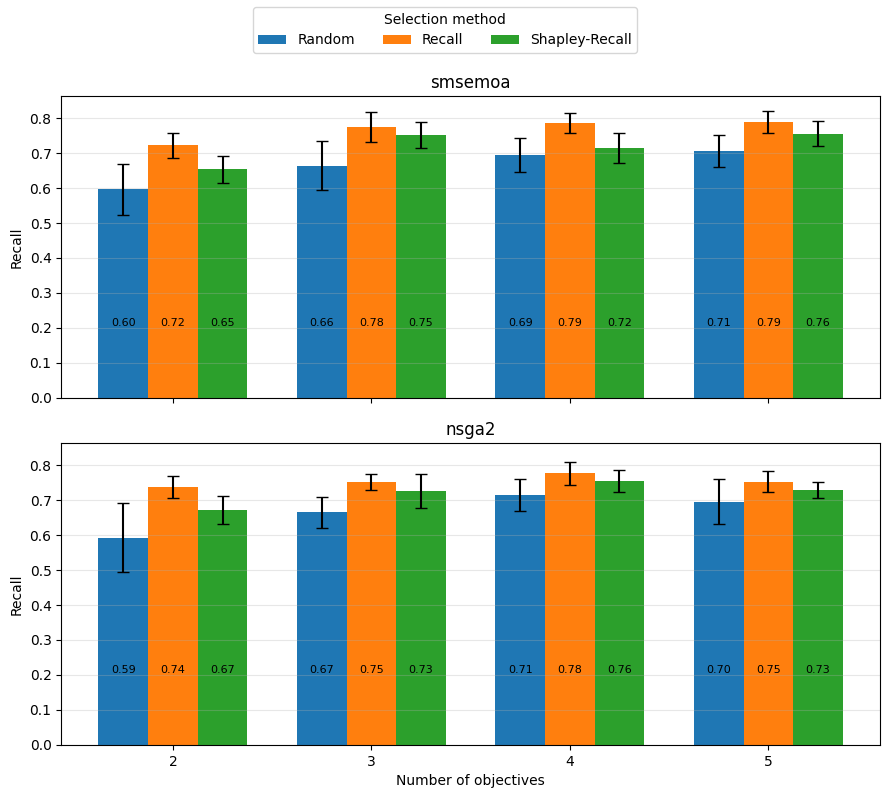

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

def annotate_bars(ax, decimals=2, y_offset=0.2):
    for bar in ax.patches:
        height = bar.get_height()
        if height <= 0:
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y_offset,
            f"{height:.{decimals}f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

agg_df = (
    df
    .groupby(["algorithm", "selection", "n_objectives"])
    .agg(
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std")
    )
    .reset_index()
)

agg_df["recall_std"] = agg_df["recall_std"].fillna(0.0)

algorithms = ["smsemoa", "nsga2"]
selections = ["random", "recall", "shapley_recall"]
n_objectives = sorted(agg_df["n_objectives"].unique())

selection_labels = {
    "random": "Random",
    "recall": "Recall",
    "shapley_recall": "Shapley-Recall"
}

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(9, 8),
    sharex=True,
    sharey=True
)

width = 0.25
x = np.arange(len(n_objectives))

for ax, algo in zip(axes, algorithms):
    sub_algo = agg_df[agg_df["algorithm"] == algo]

    for i, sel in enumerate(selections):
        sub = (
            sub_algo[sub_algo["selection"] == sel]
            .set_index("n_objectives")
            .reindex(n_objectives)
        )

        means = sub["recall_mean"].values
        stds  = sub["recall_std"].values

        ax.bar(
            x + i * width,
            means,
            width,
            yerr=stds,
            capsize=4,
            label=selection_labels[sel]
        )
    annotate_bars(ax)

    ax.set_title(algo)
    ax.set_ylabel("Recall")
    ax.set_xticks(x + width)
    ax.set_xticklabels(n_objectives)
    ax.grid(axis="y", alpha=0.3)

# shared labels
axes[-1].set_xlabel("Number of objectives")

# single legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    title="Selection method"
)

#fig.suptitle("Recall by selection strategy and algorithm", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


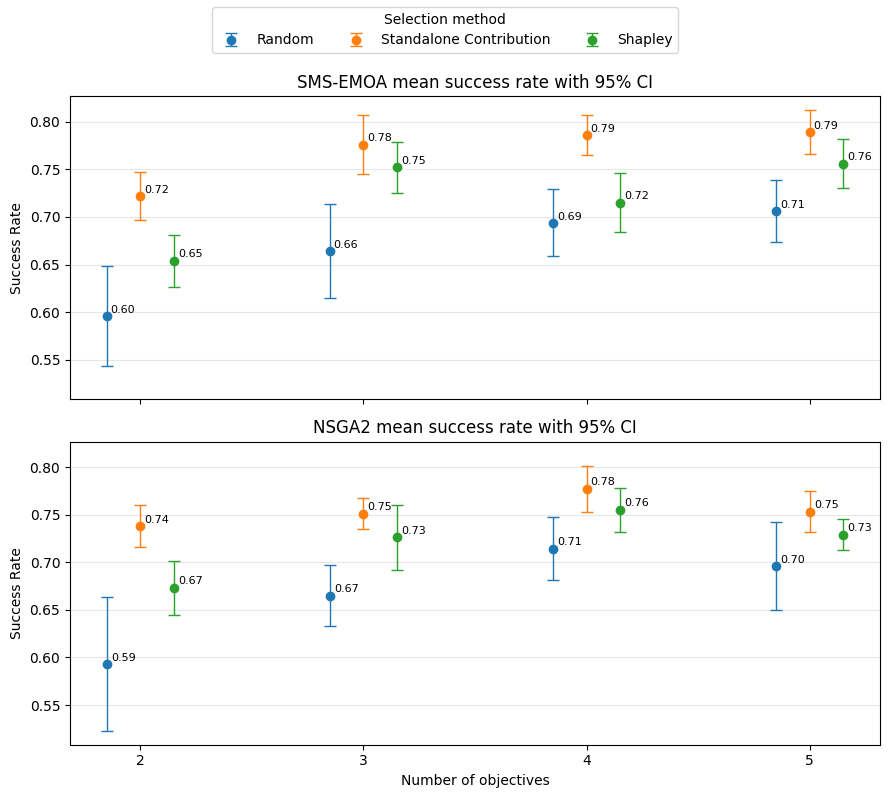

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t

def annotate_points_top_right(ax, x, means, decimals=2, x_frac=0.005, y_frac=0.005):
    """
    Place value labels slightly to the top-right of each point.
    Offsets are fractions of axis ranges for robustness.
    """
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()

    x_pad = (x_max - x_min) * x_frac
    y_pad = (y_max - y_min) * y_frac

    for xi, mean in zip(x, means):
        if mean <= 0:
            continue

        ax.text(
            xi + x_pad,
            mean + y_pad,
            f"{mean:.{decimals}f}",
            ha="left",
            va="bottom",
            fontsize=8
        )

# ------------------------------------------------------------------
# Aggregate data (mean, std, n)
# ------------------------------------------------------------------
agg_df = (
    df
    .groupby(["algorithm", "selection", "n_objectives"])
    .agg(
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        n_runs=("recall", "count")
    )
    .reset_index()
)

agg_df["recall_std"] = agg_df["recall_std"].fillna(0.0)

# 95% confidence interval
agg_df["recall_ci"] = (
    t.ppf(0.975, agg_df["n_runs"] - 1)
    * agg_df["recall_std"]
    / np.sqrt(agg_df["n_runs"])
)

algorithms = ["smsemoa", "nsga2"]
selections = ["random", "recall", "shapley_recall"]
n_objectives = sorted(agg_df["n_objectives"].unique())

selection_labels = {
    "random": "Random",
    "recall": "Standalone Contribution",
    "shapley_recall": "Shapley"
}

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(9, 8),
    sharex=True,
    sharey=True
)

x = np.arange(len(n_objectives))
offsets = np.linspace(-0.15, 0.15, len(selections))

for ax, algo in zip(axes, algorithms):
    sub_algo = agg_df[agg_df["algorithm"] == algo]

    for offset, sel in zip(offsets, selections):
        sub = (
            sub_algo[sub_algo["selection"] == sel]
            .set_index("n_objectives")
            .reindex(n_objectives)
        )

        means = sub["recall_mean"].values
        ci    = sub["recall_ci"].values
        x_pos = x + offset

        ax.errorbar(
            x_pos,
            means,
            yerr=ci,
            fmt="o",
            capsize=4,
            elinewidth=1,
            markersize=6,
            label=selection_labels[sel]
        )

        annotate_points_top_right(ax, x_pos, means)
    
    if (algo == "smsemoa"):
        ax.set_title("SMS-EMOA mean success rate with 95% CI")
    if (algo == "nsga2"):
        ax.set_title("NSGA2 mean success rate with 95% CI")
    ax.set_ylabel("Success Rate")
    ax.set_xticks(x)
    ax.set_xticklabels(n_objectives)
    ax.grid(axis="y", alpha=0.3)

    
# shared labels
axes[-1].set_xlabel("Number of objectives")

# single legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    title="Selection method"
)

fig.tight_layout(rect=[0, 0, 1, 0.93])
outpath = os.path.join("experiments", "moea", "plots", "algorithm_comparison.png")
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()



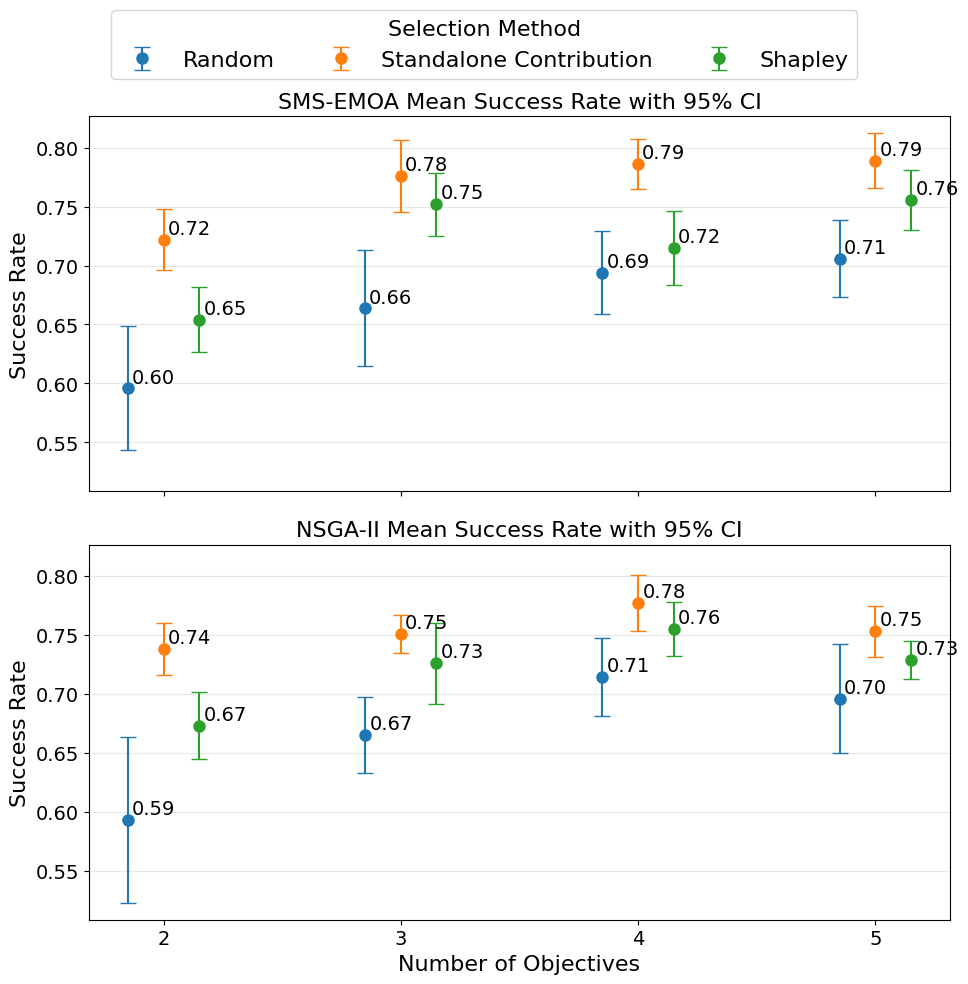

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t
import os

# -------------------------------
# GLOBAL FONT SETTINGS
# -------------------------------
plt.rcParams.update({
    "font.size": 16,     
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 16,
    "legend.title_fontsize": 16
})

def annotate_points_top_right(ax, x, means, decimals=2, x_frac=0.005, y_frac=0.005):
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()

    x_pad = (x_max - x_min) * x_frac
    y_pad = (y_max - y_min) * y_frac

    for xi, mean in zip(x, means):
        if mean <= 0:
            continue

        ax.text(
            xi + x_pad,
            mean + y_pad,
            f"{mean:.{decimals}f}",
            ha="left",
            va="bottom",
            fontsize=14   
        )

# ------------------------------------------------------------------
# Aggregate data (mean, std, n)
# ------------------------------------------------------------------
agg_df = (
    df
    .groupby(["algorithm", "selection", "n_objectives"])
    .agg(
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        n_runs=("recall", "count")
    )
    .reset_index()
)

agg_df["recall_std"] = agg_df["recall_std"].fillna(0.0)

agg_df["recall_ci"] = (
    t.ppf(0.975, agg_df["n_runs"] - 1)
    * agg_df["recall_std"]
    / np.sqrt(agg_df["n_runs"])
)

algorithms = ["smsemoa", "nsga2"]
selections = ["random", "recall", "shapley_recall"]
n_objectives = sorted(agg_df["n_objectives"].unique())

selection_labels = {
    "random": "Random",
    "recall": "Standalone Contribution",
    "shapley_recall": "Shapley"
}

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10, 10),   
    sharex=True,
    sharey=True
)

x = np.arange(len(n_objectives))
offsets = np.linspace(-0.15, 0.15, len(selections))

for ax, algo in zip(axes, algorithms):
    sub_algo = agg_df[agg_df["algorithm"] == algo]

    for offset, sel in zip(offsets, selections):
        sub = (
            sub_algo[sub_algo["selection"] == sel]
            .set_index("n_objectives")
            .reindex(n_objectives)
        )

        means = sub["recall_mean"].values
        ci    = sub["recall_ci"].values
        x_pos = x + offset

        ax.errorbar(
            x_pos,
            means,
            yerr=ci,
            fmt="o",
            capsize=6,
            elinewidth=1.5,
            markersize=8,
            label=selection_labels[sel]
        )

        annotate_points_top_right(ax, x_pos, means)

    if algo == "smsemoa":
        ax.set_title("SMS-EMOA Mean Success Rate with 95% CI")
    if algo == "nsga2":
        ax.set_title("NSGA-II Mean Success Rate with 95% CI")

    ax.set_ylabel("Success Rate")
    ax.set_xticks(x)
    ax.set_xticklabels(n_objectives)
    ax.grid(axis="y", alpha=0.3)

axes[-1].set_xlabel("Number of Objectives")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    title="Selection Method"
)

fig.tight_layout(rect=[0, 0, 1, 0.93])

# -------------------------------
# SAVE AS VECTOR PDF
# -------------------------------
outpath = os.path.join("experiments", "moea", "plots", "algorithm_comparison.png")
plt.savefig(outpath, format="png", bbox_inches="tight")

plt.show()

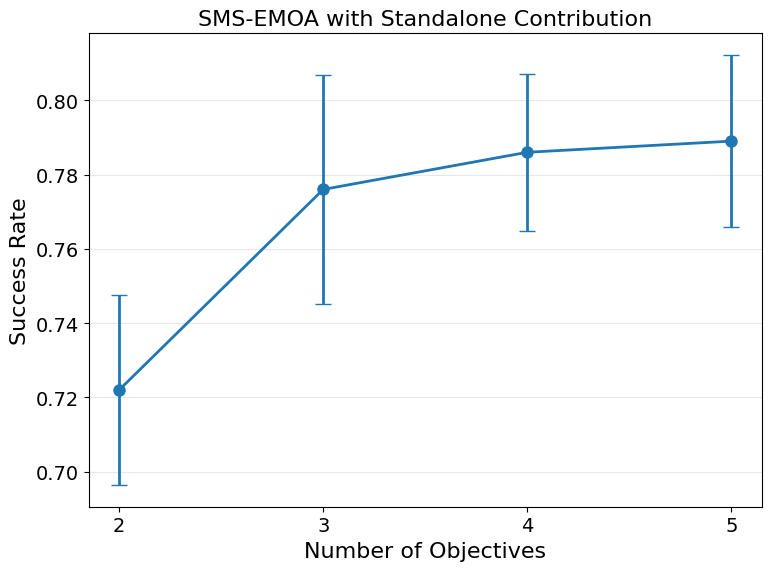

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# Filter data
# -------------------------------
simple_df = (
    agg_df[
        (agg_df["algorithm"] == "smsemoa") &
        (agg_df["selection"] == "recall")
    ]
    .sort_values("n_objectives")
)

x = simple_df["n_objectives"].values
means = simple_df["recall_mean"].values
ci = simple_df["recall_ci"].values

# -------------------------------
# Plot
# -------------------------------
plt.figure(figsize=(8,6))

plt.errorbar(
    x,
    means,
    yerr=ci,
    fmt="o-",
    capsize=6,
    markersize=8,
    linewidth=2
)

plt.xlabel("Number of Objectives")
plt.ylabel("Success Rate")
plt.title("SMS-EMOA with Standalone Contribution")

plt.xticks(x)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
outpath = os.path.join("experiments", "moea", "plots", "simple_plot.png")
plt.savefig(outpath, format="png", bbox_inches="tight")
plt.show()

In [14]:
algo_colors = {
    "nsga2": "#1f77b4",    # matplotlib default blue
    "smsemoa": "#ff7f0e"   # matplotlib default orange
}
def annotate_bar(x, height, ax=None, decimals=2, y_offset=0.01):
    if ax is None:
        ax = plt.gca()

    ax.text(
        x,
        height + y_offset,
        f"{height:.{decimals}f}",
        ha="center",
        va="bottom",
        fontsize=8
    )
    
def plot_algorithms(selection):
    n_objectives = sorted(agg_df["n_objectives"].unique())
    algorithms = ["nsga2", "smsemoa"]

    bar_width = 0.35
    group_gap = 0.6   

    x_positions = []
    labels = []

    current_x = 0
    for n in n_objectives:
        x_positions.append(current_x)               # nsga2
        x_positions.append(current_x + bar_width)   # smsemoa
        labels.append(f"{n}")
        labels.append(f"{n}")
        current_x += 2 * bar_width + group_gap
    plt.figure(figsize=(10, 5))

    for n in n_objectives:
        sub = agg_df[
            (agg_df["n_objectives"] == n) &
            (agg_df["selection"] == selection)
        ].set_index("algorithm")

        # nsga2 bar
        plt.bar(
            x_positions[2 * n_objectives.index(n)],
            sub.loc["nsga2", "recall_mean"],
            bar_width,
            yerr=sub.loc["nsga2", "recall_std"],
            capsize=4,
            color=algo_colors["nsga2"],
            label="nsga2" if n == n_objectives[0] else None
        )

        # smsemoa bar
        plt.bar(
            x_positions[2 * n_objectives.index(n) + 1],
            sub.loc["smsemoa", "recall_mean"],
            bar_width,
            yerr=sub.loc["smsemoa", "recall_std"],
            capsize=4,
            color=algo_colors["smsemoa"],
            label="smsemoa" if n == n_objectives[0] else None
        )
    plt.xticks(x_positions, labels)
    plt.ylabel("Recall")
    plt.xlabel("Objectives")
    plt.title(f"Algorithm comparison ({selection} selection)")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


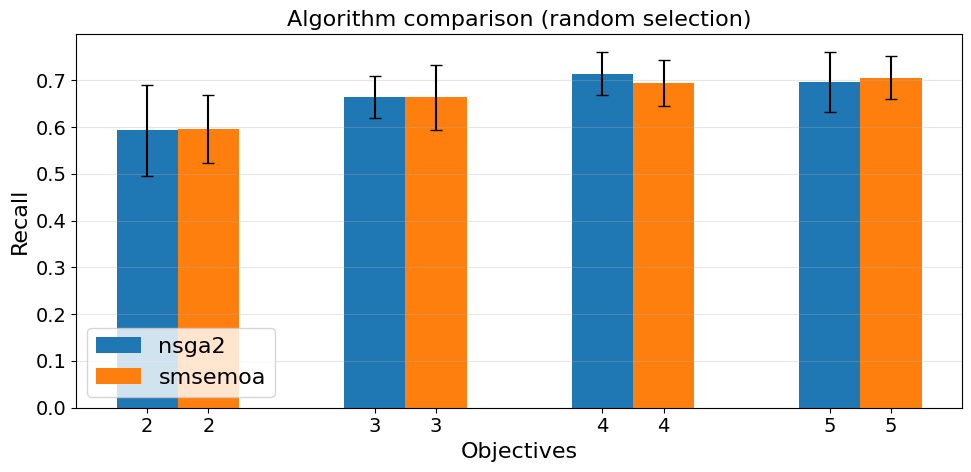

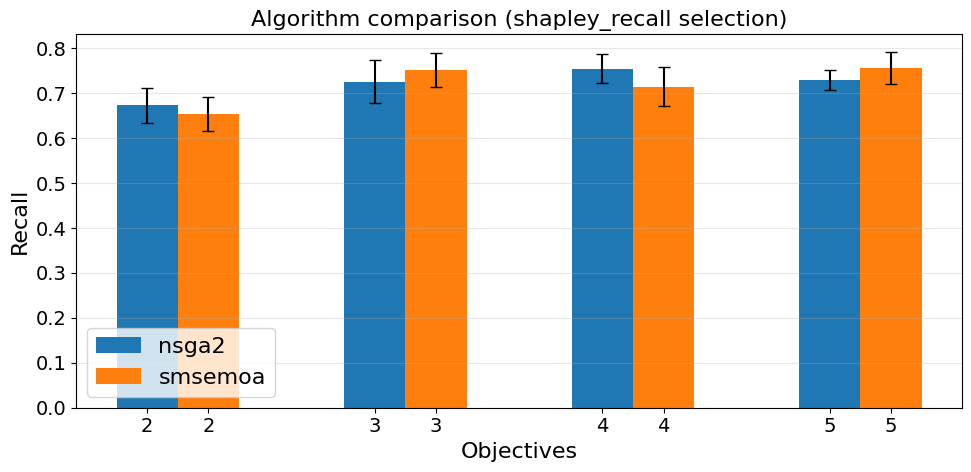

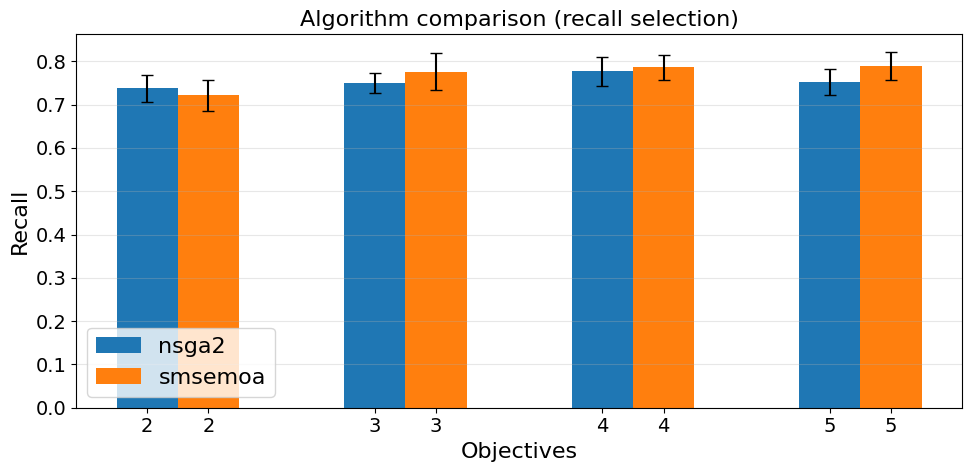

In [15]:
selections = ["random", "shapley_recall", "recall"]
for selection in selections:
    plot_algorithms(selection)

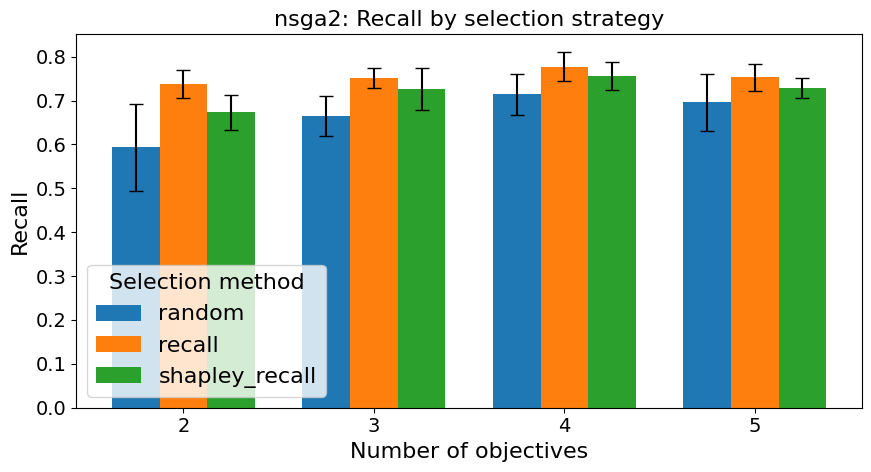

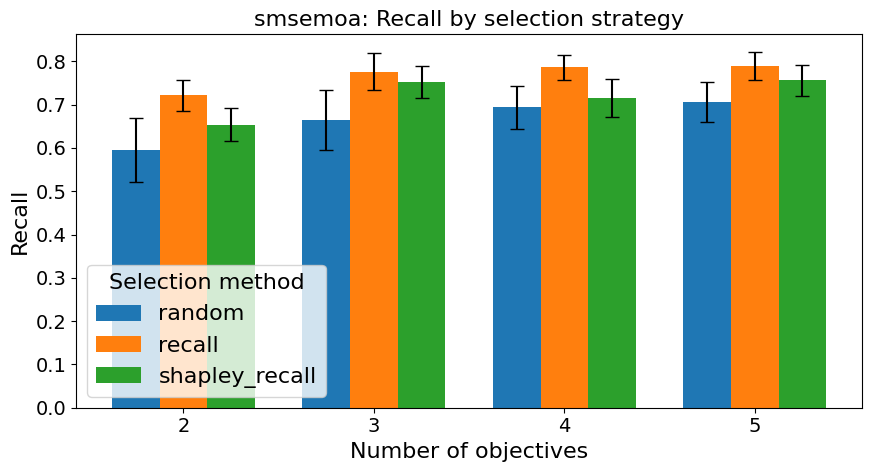

In [16]:
import matplotlib.pyplot as plt
import numpy as np

agg_df = (
    df
    .groupby(["algorithm", "selection", "n_objectives"])
    .agg(
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std")
    )
    .reset_index()
)

agg_df["recall_std"] = agg_df["recall_std"].fillna(0.0)

selections = ["random", "recall", "shapley_recall"]
n_objectives = sorted(agg_df["n_objectives"].unique())

for algorithm in agg_df["algorithm"].unique():
    sub_algo = agg_df[agg_df["algorithm"] == algorithm]

    x = np.arange(len(n_objectives))
    width = 0.25

    plt.figure(figsize=(9, 5))

    for i, sel in enumerate(selections):
        sub = (
            sub_algo[sub_algo["selection"] == sel]
            .set_index("n_objectives")
            .reindex(n_objectives)
        )

        means = sub["recall_mean"].fillna(0).values
        stds  = sub["recall_std"].fillna(0).values

        plt.bar(
            x + i * width,
            means,
            width,
            yerr=stds,
            capsize=5,
            label=sel
        )

    plt.xlabel("Number of objectives")
    plt.ylabel("Recall")
    plt.title(f"{algorithm}: Recall by selection strategy")
    plt.xticks(x + width, n_objectives)
    plt.legend(title="Selection method")
    plt.tight_layout()
    plt.show()


In [17]:
recall_obj = results
for result in results:
    if result["algorithm"]=="smsemoa" and result["n_objectives"]==5:
        if result["selection"]=="recall":
            print("Recall objectives: ", result["objectives"])
        elif result["selection"]=="shapley_recall":
            print("Shapley objectives: ", result["objectives"])

Recall objectives:  ('stft_kl_divergence', 'stft_js_divergence', 'stft_cosh', 'iirt_cosh', 'cqt_kl_divergence_populations')
Recall objectives:  ('stft_kl_divergence', 'stft_js_divergence', 'stft_cosh', 'iirt_cosh', 'cqt_kl_divergence_populations')
Recall objectives:  ('stft_kl_divergence', 'stft_js_divergence', 'stft_cosh', 'iirt_cosh', 'cqt_kl_divergence_populations')
Recall objectives:  ('stft_kl_divergence', 'stft_js_divergence', 'stft_cosh', 'iirt_cosh', 'cqt_kl_divergence_populations')
Recall objectives:  ('stft_kl_divergence', 'stft_js_divergence', 'stft_cosh', 'iirt_cosh', 'cqt_kl_divergence_populations')
Recall objectives:  ('stft_kl_divergence', 'stft_js_divergence', 'stft_cosh', 'iirt_cosh', 'cqt_kl_divergence_populations')
Recall objectives:  ('stft_kl_divergence', 'stft_js_divergence', 'stft_cosh', 'iirt_cosh', 'cqt_kl_divergence_populations')
Recall objectives:  ('stft_kl_divergence', 'stft_js_divergence', 'stft_cosh', 'iirt_cosh', 'cqt_kl_divergence_populations')
Recall o

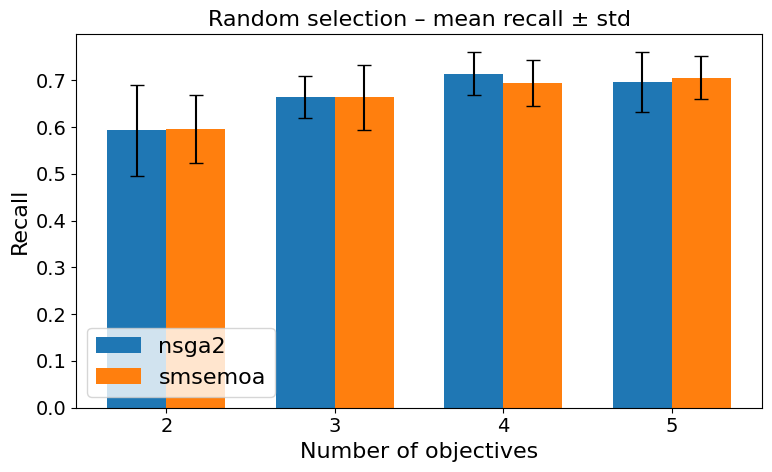

In [18]:
import matplotlib.pyplot as plt
import numpy as np

random_df = (
    df[df["selection"] == "random"]
    .groupby(["algorithm", "n_objectives"])
    .agg(
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std")
    )
    .reset_index()
)
algorithms = random_df["algorithm"].unique()
n_objectives = sorted(random_df["n_objectives"].unique())

x = np.arange(len(n_objectives))
width = 0.35

plt.figure(figsize=(8, 5))

for i, algo in enumerate(algorithms):
    sub = random_df[random_df["algorithm"] == algo]
    sub = sub.set_index("n_objectives").loc[n_objectives]

    plt.bar(
        x + i * width,
        sub["recall_mean"],
        width,
        yerr=sub["recall_std"],
        capsize=5,
        label=algo
    )

plt.xlabel("Number of objectives")
plt.ylabel("Recall")
plt.title("Random selection – mean recall ± std")
plt.xticks(x + width / 2, n_objectives)
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
df[df.selection == "random"].groupby(
    ["algorithm", "n_objectives"]
)["recall"].describe()


count   mean       std   min     25%    50%     75%  \
algorithm n_objectives                                                        
nsga2     2              10.0  0.593  0.098212  0.34  0.5825  0.625  0.6300   
          3              10.0  0.665  0.045277  0.60  0.6300  0.660  0.7125   
          4              10.0  0.714  0.046236  0.64  0.6800  0.715  0.7475   
          5              10.0  0.696  0.064498  0.58  0.6650  0.695  0.7400   
smsemoa   2              10.0  0.596  0.073666  0.46  0.5600  0.595  0.6475   
          3              10.0  0.664  0.069314  0.56  0.6050  0.670  0.7225   
          4              10.0  0.694  0.049261  0.61  0.6675  0.695  0.7100   
          5              10.0  0.706  0.045509  0.60  0.6950  0.710  0.7375   

                         max  
algorithm n_objectives        
nsga2     2             0.69  
          3             0.72  
          4             0.78  
          5             0.80  
smsemoa   2             0.69  
          3             0.76  
          4             0.77  
          5             0.76